c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature nam

Accuracy: 0.9486
Log Loss (pérdida logarítmica): 0.1371
AUC: 0.9468
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      9716
           1       0.82      0.49      0.61       881

    accuracy                           0.95     10597
   macro avg       0.89      0.74      0.79     10597
weighted avg       0.94      0.95      0.94     10597



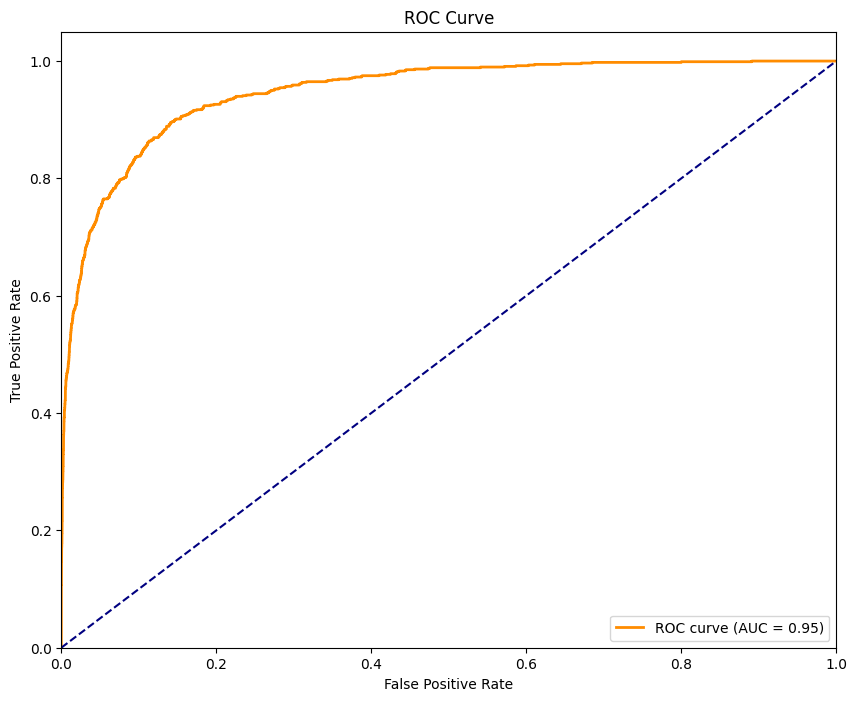

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from tpot.builtins import StackingEstimator
from xgboost import XGBClassifier
from tpot.export_utils import set_param_recursive
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report

# Cargar los datos (ajusta la ruta y asegúrate de que el nombre de la columna objetivo es 'children')
tpot_data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
features = tpot_data.drop(columns=['children'])  # Ajusta 'children' según tu columna objetivo
target = tpot_data['children']

# Dividir los datos en entrenamiento y prueba
training_features, testing_features, training_target, testing_target = \
    train_test_split(features, target, test_size=0.2, random_state=42)

# Crear el pipeline optimizado por TPOT
exported_pipeline = make_pipeline(
    StackingEstimator(estimator=MLPClassifier(alpha=0.001, learning_rate_init=0.1)),
    MinMaxScaler(),
    XGBClassifier(learning_rate=0.1, max_depth=10, min_child_weight=6, n_estimators=100, n_jobs=1, subsample=1.0, verbosity=0)
)

# Asegurarse de que la semilla aleatoria esté fijada para reproducibilidad
set_param_recursive(exported_pipeline.steps, 'random_state', 42)

# Entrenar el pipeline con los datos de entrenamiento
exported_pipeline.fit(training_features, training_target)

# Realizar predicciones en el conjunto de prueba
predictions = exported_pipeline.predict(testing_features)
pred_proba = exported_pipeline.predict_proba(testing_features)[:, 1]

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(testing_target, predictions)
logloss = log_loss(testing_target, pred_proba)
auc = roc_auc_score(testing_target, pred_proba)

# Mostrar resultados
print(f"Accuracy: {accuracy:.4f}")
print(f"Log Loss (pérdida logarítmica): {logloss:.4f}")
print(f"AUC: {auc:.4f}")
print(classification_report(testing_target, predictions))

# Graficar la curva ROC
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(testing_target, pred_proba)
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [2]:
import pandas as pd
from datetime import datetime

# Cargar el archivo de prueba (ajusta la ruta si es necesario)
test_data = pd.read_csv('hoteles-prueba-limpio-normalizado.csv')

# Extraer la columna "id" y preparar los datos para predicción
test_ids = test_data['id']
X_test_data = test_data.drop(columns=['id'])

# Generar las probabilidades de predicción usando el pipeline optimizado por TPOT
y_pred_proba_test = exported_pipeline.predict_proba(X_test_data)[:, 1]

# Crear el archivo con timestamp
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M")
file_name = f'kaggle_submission_{timestamp}.csv'
kaggle_submission = pd.DataFrame({'id': test_ids, 'prob': y_pred_proba_test})

# Guardar el archivo para Kaggle
kaggle_submission.to_csv(file_name, index=False)

print(f"Archivo '{file_name}' creado con éxito para Kaggle.")

c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
c:\Users\Javier_Castillo\.conda\envs\arquitectura\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


Archivo 'kaggle_submission_2024_10_19_14_36.csv' creado con éxito para Kaggle.
